In [1]:
import pandas as pd
import numpy as np

# ТЗ

Описание задачи Вам нужно исследовать данные о прохождении игроками уровней match3-игры и выполнить следующие задания:

Задание 1
Предложить метрику, описывающую сложность уровней, и рассчитать ее.

Задание 2
По результатам предыдущего задания разделить уровни на группы по сложности и сделать вывод о плотности расположения сложных уровней в игре.
Задание 3
Рассчитать "воронку" прохождения уровней новым пользователем после установки игры.
Также мы хотели бы получить от вас комментарий по выполнению тестового задания. Он не должен быть очень большим. Нам интересно было бы узнать:

примерную оценку времени, которое вы потратили на выполнение задания;
комментарии по сформированной метрике (п1): почему данная метрика будет показательной;
возникали ли проблемы при выполнении тестового задания.

Входные данные — файл plr_smpl_attempts.csv.gz, содержащий лог событий за определенный промежуток времени по первым 500 уровням в игре. Файл содержит четыре колонки:
- uid — уникальный id игрока;
- action — ‘completed’ для успешной попытки прохождения уровня, ‘failed’ для неуспешной;
- level — уровень, на котором произошло событие;
- event_time — event_time/1000 является unix timestamp времени получения события.

Мы ожидаем, что для выполнения задания вы будете использовать Python. Ответ на задание лучше всего отправлять в формате jupyter notebook. По срокам выполнения тестового задания мы вас не ограничиваем — вы можете прислать его, когда будете полностью в нем уверены. Как правило, кандидаты справляются с ним за одну рабочую неделю.

# Загружаем файл

In [7]:
df = pd.read_csv('plr_smpl_attempts.csv', sep=';')

In [8]:
len(df)

22231214

In [9]:
df.head()

,uid,action,level,event_time
0,elljQ2EySG03MDU0MTE3MTAyMTE3MA,failed,113,1512086924640
1,elljQ2EySG03MDU0MTE3MTAyMTE3MA,failed,113,1512086924640
2,elljQ2EySG03MDU0MTE3MTAyMTE3MA,failed,113,1512086924640
3,elljQ2EySG03MDU0MTE3MTAyMTE3MA,failed,113,1512086924640
4,elljQ2EySG03MDU0MTE3MTAyMTE3MA,failed,113,1512086924640


In [10]:
df['action'].value_counts(normalize=True)

action
failed       0.843163
completed    0.156837
Name: proportion, dtype: float64

# Задание 1 Предложить метрику, описывающую сложность уровней, и рассчитать ее.

## Преобразуем таргет в 1 и 0

In [13]:
df['action'] = df['action'].apply(lambda row: 1 if row == 'failed' else 0)

In [14]:
df['action'].dtypes

dtype('int64')

## Метрика - доля неудачных попыток на каждом уровне

In [16]:
df.groupby('level')['action'].agg(['count','mean'])

,count,mean
level,,
1,25157,0.000676
2,23313,0.037618
3,23634,0.082381
4,21636,0.014513
5,27192,0.236209
...,...,...
496,2062,0.796799
497,1148,0.641986
498,2409,0.833956


<Axes: xlabel='level'>

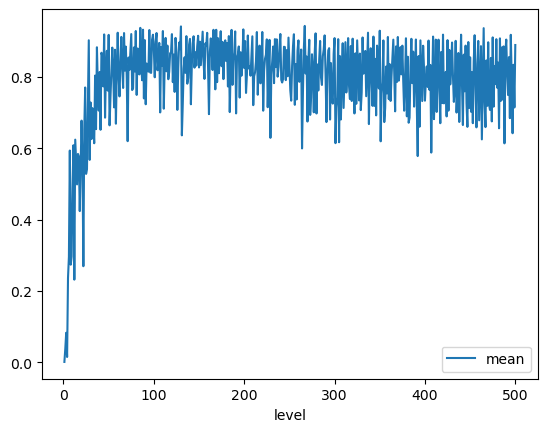

In [17]:
df.groupby('level')['action'].agg(['mean']).plot()

`Метрика - доля неудачных попыток на каждом уровне`

## Метрика - Доля игроков, которые не прошли уровень с первого раза

In [20]:
df.head()

,uid,action,level,event_time
0,elljQ2EySG03MDU0MTE3MTAyMTE3MA,1,113,1512086924640
1,elljQ2EySG03MDU0MTE3MTAyMTE3MA,1,113,1512086924640
2,elljQ2EySG03MDU0MTE3MTAyMTE3MA,1,113,1512086924640
3,elljQ2EySG03MDU0MTE3MTAyMTE3MA,1,113,1512086924640
4,elljQ2EySG03MDU0MTE3MTAyMTE3MA,1,113,1512086924640


### Потренируемся на отдельном уровне

In [22]:
t = df[df['level'] == 113]
t

,uid,action,level,event_time
0,elljQ2EySG03MDU0MTE3MTAyMTE3MA,1,113,1512086924640
1,elljQ2EySG03MDU0MTE3MTAyMTE3MA,1,113,1512086924640
2,elljQ2EySG03MDU0MTE3MTAyMTE3MA,1,113,1512086924640
3,elljQ2EySG03MDU0MTE3MTAyMTE3MA,1,113,1512086924640
4,elljQ2EySG03MDU0MTE3MTAyMTE3MA,1,113,1512086924640
...,...,...,...,...
22229182,aVhaY3RjZEY1MDQzMDI3MTAyMTE0MQ,1,113,1514207760822
22229183,aVhaY3RjZEY1MDQzMDI3MTAyMTE0MQ,1,113,1514207760591
22229184,aVhaY3RjZEY1MDQzMDI3MTAyMTE0MQ,1,113,1514207760591
22229185,aVhaY3RjZEY1MDQzMDI3MTAyMTE0MQ,1,113,1514207760591


### Метод rank()

In [24]:
#Метод rank() в библиотеке Pandas присваивает ранги элементам DataFrame на основе их значений. 
t['rnk'] = t.sort_values('event_time').groupby(['level', 'uid'])['event_time'].rank(method = 'first')

C:\Users\ryagu\AppData\Local\Temp\ipykernel_8144\3460281197.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  t['rnk'] = t.sort_values('event_time').groupby(['level', 'uid'])['event_time'].rank(method = 'first')


In [25]:
t[t['rnk'] == 1]

,uid,action,level,event_time,rnk
0,elljQ2EySG03MDU0MTE3MTAyMTE3MA,1,113,1512086924640,1.0
426,RE9iT0VkMmkwMjUwMTI3MTAyMDE4MA,1,113,1512146434418,1.0
1354,cDBlZlZuRjAwMzU1NDE3MTAyMTE4Mg,1,113,1512096831695,1.0
1612,a2FqVG5mcTQyMjcwODA3MTAyOTA4Mg,0,113,1512097744297,1.0
3271,WHNRT1ZPTzQ2MzIzOTA3MTAyMDE0MQ,0,113,1512136177025,1.0
...,...,...,...,...,...
22226613,Z0pxTkk3T2w4MTUxNjE3MTAyMTEyMg,1,113,1514188686859,1.0
22227559,THZIYXZVaU01MjgyMTE3MTAyMTEzMA,1,113,1514204444724,1.0
22227810,SzJvRXcxOEIwMzk0MjE3MTAyOTA4Mg,1,113,1514230050322,1.0
22228410,NGtWM2pCaG43MTI1NDE3MTAyOTAwMw,1,113,1514203803703,1.0


### Альтернативный метод first()

In [27]:
tt = t.sort_values('event_time').groupby(['level', 'uid'])[['event_time', 'action']].first().reset_index()
tt

,level,uid,event_time,action
0,113,M000Y3dYeUUyMjIxODE3MTAyOTAwMQ,1513482740555,1
1,113,M001QWtGRzUzMDQwMzI3MTAyMjE3MA,1514757067147,1
2,113,M011NDZ0QXMwMzAzMzI3MTAyMDE1MA,1514064284588,1
3,113,M01OdkFlVHExNTU1NDE3MTAyMDE2MA,1514424283119,1
4,113,M01icWdWNUs0NDQ1OTE3MTAyOTAzMg,1512892853409,1
...,...,...,...,...
17273,113,eno3R3g2T0M5MzU1ODA3MTAyMTE0MA,1513882163990,0
17274,113,enpSejVXWnE3MzYxMTE3MTAyMDE3MA,1513631015412,1
17275,113,enpVekM1Y2E0MjM1MTI3MTAyOTA0Mg,1512561949272,1
17276,113,enpnSkJRUmwyMTYyNTA3MTAyOTA4Mg,1514172585192,1


In [28]:
tt[tt['uid'] == 'M000Y3dYeUUyMjIxODE3MTAyOTAwMQ']

,level,uid,event_time,action
0,113,M000Y3dYeUUyMjIxODE3MTAyOTAwMQ,1513482740555,1


In [29]:
t[(t['rnk'] == 1)&(t['uid'] == 'M000Y3dYeUUyMjIxODE3MTAyOTAwMQ')]

,uid,action,level,event_time,rnk
10987832,M000Y3dYeUUyMjIxODE3MTAyOTAwMQ,1,113,1513482740555,1.0


### Дубликаты

In [31]:
t[(t['level'] == 113)&(t['uid'] == 'M000Y3dYeUUyMjIxODE3MTAyOTAwMQ')]

,uid,action,level,event_time,rnk
10987828,M000Y3dYeUUyMjIxODE3MTAyOTAwMQ,1,113,1513482740555,5.0
10987829,M000Y3dYeUUyMjIxODE3MTAyOTAwMQ,1,113,1513482740555,4.0
10987830,M000Y3dYeUUyMjIxODE3MTAyOTAwMQ,1,113,1513482740555,3.0
10987831,M000Y3dYeUUyMjIxODE3MTAyOTAwMQ,1,113,1513482740555,2.0
10987832,M000Y3dYeUUyMjIxODE3MTAyOTAwMQ,1,113,1513482740555,1.0
10987833,M000Y3dYeUUyMjIxODE3MTAyOTAwMQ,1,113,1513553908542,14.0
10987834,M000Y3dYeUUyMjIxODE3MTAyOTAwMQ,1,113,1513553908542,16.0
10987835,M000Y3dYeUUyMjIxODE3MTAyOTAwMQ,1,113,1513553908542,15.0
10987836,M000Y3dYeUUyMjIxODE3MTAyOTAwMQ,1,113,1513540538178,7.0
10987837,M000Y3dYeUUyMjIxODE3MTAyOTAwMQ,1,113,1513540538178,6.0


In [32]:
len(df)

22231214

In [33]:
len(df.drop_duplicates()) # есть дубликаты

10387712

In [34]:
df.head()

,uid,action,level,event_time
0,elljQ2EySG03MDU0MTE3MTAyMTE3MA,1,113,1512086924640
1,elljQ2EySG03MDU0MTE3MTAyMTE3MA,1,113,1512086924640
2,elljQ2EySG03MDU0MTE3MTAyMTE3MA,1,113,1512086924640
3,elljQ2EySG03MDU0MTE3MTAyMTE3MA,1,113,1512086924640
4,elljQ2EySG03MDU0MTE3MTAyMTE3MA,1,113,1512086924640


In [35]:
df.columns

Index(['uid', 'action', 'level', 'event_time'], dtype='object')

In [36]:
# считаем число одинаковых записей для игрока
df = df.groupby(['uid', 'action', 'level', 'event_time'])['uid'].count()

In [37]:
df

uid                             action  level  event_time   
M000MjVPdEM0MzMzNzA3MTAyMDE5MQ  1       95     1513224808476    5
                                               1513253353017    1
                                               1513253543747    2
                                               1513261453988    6
M000Y3dYeUUyMjIxODE3MTAyOTAwMQ  0       90     1512249715495    1
                                                               ..
enpzeGNhWUk4MjE0MzE3MTAyMDE5MA  1       153    1513462622075    1
                                        154    1513462915647    1
                                               1513463503020    3
                                        176    1514674697079    2
                                               1514674966884    1
Name: uid, Length: 10387712, dtype: int64

In [38]:
df.name = 'count'

In [39]:
df = df.reset_index()

In [40]:
df

,uid,action,level,event_time,count
0,M000MjVPdEM0MzMzNzA3MTAyMDE5MQ,1,95,1513224808476,5
1,M000MjVPdEM0MzMzNzA3MTAyMDE5MQ,1,95,1513253353017,1
2,M000MjVPdEM0MzMzNzA3MTAyMDE5MQ,1,95,1513253543747,2
3,M000MjVPdEM0MzMzNzA3MTAyMDE5MQ,1,95,1513261453988,6
4,M000Y3dYeUUyMjIxODE3MTAyOTAwMQ,0,90,1512249715495,1
...,...,...,...,...,...
10387707,enpzeGNhWUk4MjE0MzE3MTAyMDE5MA,1,153,1513462622075,1
10387708,enpzeGNhWUk4MjE0MzE3MTAyMDE5MA,1,154,1513462915647,1
10387709,enpzeGNhWUk4MjE0MzE3MTAyMDE5MA,1,154,1513463503020,3
10387710,enpzeGNhWUk4MjE0MzE3MTAyMDE5MA,1,176,1514674697079,2


In [41]:
df[(df['uid']=='M000Y3dYeUUyMjIxODE3MTAyOTAwMQ')&(df['level'] == 113)]

,uid,action,level,event_time,count
76,M000Y3dYeUUyMjIxODE3MTAyOTAwMQ,1,113,1513482740555,5
77,M000Y3dYeUUyMjIxODE3MTAyOTAwMQ,1,113,1513540538178,2
78,M000Y3dYeUUyMjIxODE3MTAyOTAwMQ,1,113,1513542854279,3
79,M000Y3dYeUUyMjIxODE3MTAyOTAwMQ,1,113,1513547997358,3
80,M000Y3dYeUUyMjIxODE3MTAyOTAwMQ,1,113,1513553908542,3


### Первая попытка

In [43]:
t = df.sort_values(['level', 'uid', 'event_time']).groupby(['level','uid']).first().reset_index()

In [44]:
t

,level,uid,action,event_time,count
0,1,M001TWRFNWc5MjQ1MDI3MTAyMjE5MA,0,1512855813696,1
1,1,M001VTlGalU5MzcwMTI3MTAyMjE5Mg,0,1514578577760,1
2,1,M010Z2VmOFgzMzgwMTI3MTAyMjE4Mg,0,1514489117415,1
3,1,M01QQlBMVmo1NTcyODA3MTAyMjE4MQ,0,1513557080655,1
4,1,M01TMDNDdzA0MDkwNzE3MTAyMjE2MA,0,1512535403271,1
...,...,...,...,...,...
3803853,500,eTdScDhBVVE2NTUwNDE3MTAyMDE2MA,0,1513738782236,1
3803854,500,eU5xSFk1R3kzMjMxNzE3MTAyOTAxMg,1,1514323669995,3
3803855,500,eVZZWENPOVY0MjEzMzI3MTAyMDE1MA,0,1514005432695,1
3803856,500,elpFRWtucDUzMjIzNDE3MTAyMDE3MA,0,1514627403229,1


In [45]:
t.columns = ['level', 'uid', 'failed', 'event_time', 'count']

In [46]:
t.columns

Index(['level', 'uid', 'failed', 'event_time', 'count'], dtype='object')

In [47]:
t.head()

,level,uid,failed,event_time,count
0,1,M001TWRFNWc5MjQ1MDI3MTAyMjE5MA,0,1512855813696,1
1,1,M001VTlGalU5MzcwMTI3MTAyMjE5Mg,0,1514578577760,1
2,1,M010Z2VmOFgzMzgwMTI3MTAyMjE4Mg,0,1514489117415,1
3,1,M01QQlBMVmo1NTcyODA3MTAyMjE4MQ,0,1513557080655,1
4,1,M01TMDNDdzA0MDkwNzE3MTAyMjE2MA,0,1512535403271,1


In [49]:
t.groupby('level')['failed'].mean()

level
1      0.000331
2      0.016143
3      0.017418
4      0.005450
5      0.045673
         ...   
496    0.441109
497    0.272059
498    0.451456
499    0.353808
500    0.515152
Name: failed, Length: 500, dtype: float64

<Axes: xlabel='level'>

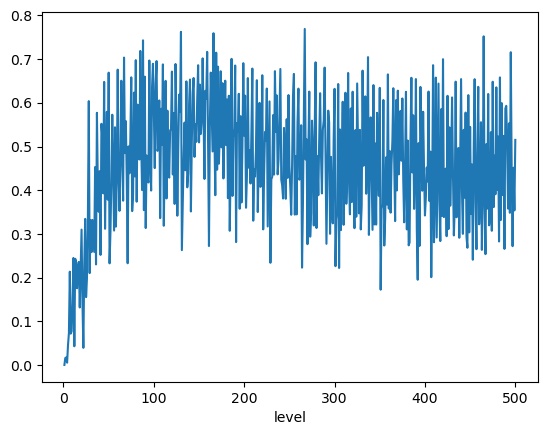

In [51]:
t.groupby('level')['failed'].mean().plot()

### Вопрос по метрике

Возможно такое, что пользователь играет где-то в офлайне и затем при подключении его к интернету, вся информация о его действиях подгружается в один момент времени. Это объясняет тот факт что у пользователя несколько попыток на разных уровнях в один момент времени. Тогда наша вторая метрика не имеет смысла.

Доказательства ниже

In [53]:
df = pd.read_csv('plr_smpl_attempts.csv', sep=';')

In [55]:
d = df.groupby(['uid', 'event_time'])['event_time'].count()

In [57]:
d.sort_values(ascending=False)

uid                             event_time   
NWVTWWt4UzIxMDUxMTA3MTAyOTA5Mg  1514370274359    1688
U0NVNk4xSlAxMjc0MzE3MTAyMDE1MA  1514463213261    1561
Z3o0TmFoeTQ1MjMyOTE3MTAyOTAxMg  1513449317511    1408
SHIwdkltZlk0NTUxNjE3MTAyOTA5Mg  1514006798622    1233
dlE1TGo1ZjU1NDExOTA3MTAyMDE5MA  1514078786418    1182
                                                 ... 
VHVDRldHQm80MjgwMjA3MTAyMTE2Mg  1512566347403       1
                                1512653833987       1
                                1512660643378       1
                                1512727445949       1
enpzeGNhWUk4MjE0MzE3MTAyMDE5MA  1514674966884       1
Name: event_time, Length: 5486162, dtype: int64

In [59]:
df[(df['uid'] == 'NWVTWWt4UzIxMDUxMTA3MTAyOTA5Mg')&(df['event_time'] ==1514370274359)]['level'].value_counts()

level
154    344
144     77
197     54
214     53
167     50
      ... 
212      1
211      1
190      1
202      1
203      1
Name: count, Length: 121, dtype: int64

# Задание 2 По результатам предыдущего задания разделить уровни на группы по сложности и сделать вывод о плотности расположения сложных уровней в игре.

## Метрика - доля тех, кто отваливается после уровня: либо навсегда, либо на время

### Количество уникальных пользователей, играющих на уровне

In [61]:
# число попыток на каждом уровне
df.groupby('level')['uid'].count()

level
1      25157
2      23313
3      23634
4      21636
5      27192
       ...  
496     2062
497     1148
498     2409
499     1424
500     3526
Name: uid, Length: 500, dtype: int64

In [62]:
# число уникальных пользователей на каждом уровне
df.groupby('level')['uid'].nunique()

level
1      24162
2      22177
3      21415
4      20916
5      20625
       ...  
496      433
497      408
498      412
499      407
500      429
Name: uid, Length: 500, dtype: int64

<Axes: xlabel='level'>

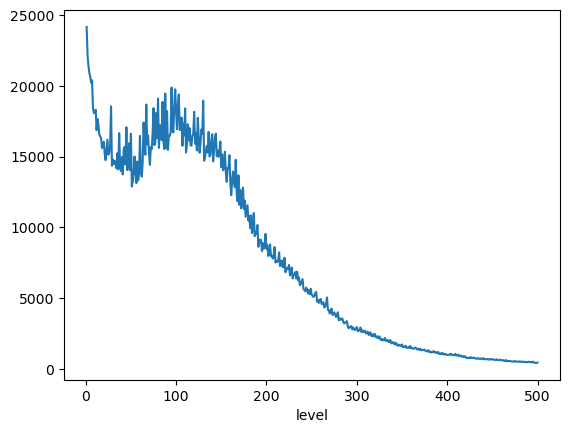

In [63]:
df.groupby('level')['uid'].nunique().plot()

In [65]:
df

,uid,action,level,event_time
0,elljQ2EySG03MDU0MTE3MTAyMTE3MA,failed,113,1512086924640
1,elljQ2EySG03MDU0MTE3MTAyMTE3MA,failed,113,1512086924640
2,elljQ2EySG03MDU0MTE3MTAyMTE3MA,failed,113,1512086924640
3,elljQ2EySG03MDU0MTE3MTAyMTE3MA,failed,113,1512086924640
4,elljQ2EySG03MDU0MTE3MTAyMTE3MA,failed,113,1512086924640
...,...,...,...,...
22231209,R2l2aXM5bGM1MTExMzE3MTAyMDE4MQ,failed,214,1514189810163
22231210,R2l2aXM5bGM1MTExMzE3MTAyMDE4MQ,failed,214,1514189810163
22231211,R2l2aXM5bGM1MTExMzE3MTAyMDE4MQ,completed,213,1514189810163
22231212,R2l2aXM5bGM1MTExMzE3MTAyMDE4MQ,failed,213,1514189810163


In [66]:
# переводим даты в читаемый вид
df['dt'] = pd.to_datetime(df['event_time']/1000,unit='s')

In [67]:
df

,uid,action,level,event_time,dt
0,elljQ2EySG03MDU0MTE3MTAyMTE3MA,failed,113,1512086924640,2017-12-01 00:08:44.640000105
1,elljQ2EySG03MDU0MTE3MTAyMTE3MA,failed,113,1512086924640,2017-12-01 00:08:44.640000105
2,elljQ2EySG03MDU0MTE3MTAyMTE3MA,failed,113,1512086924640,2017-12-01 00:08:44.640000105
3,elljQ2EySG03MDU0MTE3MTAyMTE3MA,failed,113,1512086924640,2017-12-01 00:08:44.640000105
4,elljQ2EySG03MDU0MTE3MTAyMTE3MA,failed,113,1512086924640,2017-12-01 00:08:44.640000105
...,...,...,...,...,...
22231209,R2l2aXM5bGM1MTExMzE3MTAyMDE4MQ,failed,214,1514189810163,2017-12-25 08:16:50.163000107
22231210,R2l2aXM5bGM1MTExMzE3MTAyMDE4MQ,failed,214,1514189810163,2017-12-25 08:16:50.163000107
22231211,R2l2aXM5bGM1MTExMzE3MTAyMDE4MQ,completed,213,1514189810163,2017-12-25 08:16:50.163000107
22231212,R2l2aXM5bGM1MTExMzE3MTAyMDE4MQ,failed,213,1514189810163,2017-12-25 08:16:50.163000107


In [68]:
df['dt'].apply(['min', 'max'])

min   2017-12-01 00:00:00.272000074
max   2017-12-31 23:59:59.867000103
Name: dt, dtype: datetime64[ns]

## Смотрим дату первой активности каждого пользователя

In [76]:
#мы можем извлекать различные части из объекта datetime, такие как месяцы, даты и т. д.
df['day'] = df['dt'].dt.date

In [77]:
t = df.groupby('uid')['day'].min()

In [78]:
t = t.reset_index()

In [79]:
t

,uid,day
0,M000MjVPdEM0MzMzNzA3MTAyMDE5MQ,2017-12-14
1,M000Y3dYeUUyMjIxODE3MTAyOTAwMQ,2017-12-02
2,M001QWtGRzUzMDQwMzI3MTAyMjE3MA,2017-12-20
3,M001TWRFNWc5MjQ1MDI3MTAyMjE5MA,2017-12-09
4,M001VTlGalU5MzcwMTI3MTAyMjE5Mg,2017-12-29
...,...,...
196083,enpyUUR1Z3oyNTAwMjI3MTAyMDE0MA,2017-12-02
196084,enpya243UGc0MzAxMDA3MTAyMTE3MA,2017-12-09
196085,enpzWUp4TGMxMzIzMjA3MTAyMDE3Mg,2017-12-14
196086,enpzZVJEcDQ4MjM0NDA3MTAyMTE3MA,2017-12-28


## Активность игроков по дням

<Axes: xlabel='day'>

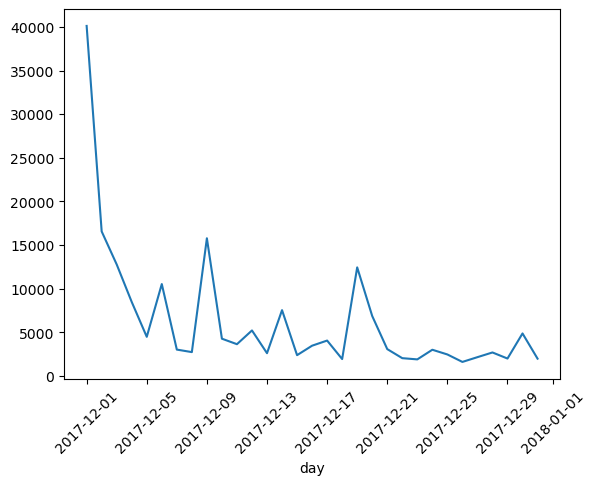

In [81]:
# на графике показано количество игроков, которые начали играть в определенный день
# т.е. первый день, когда была зафиксирована активность пользователя
t.groupby('day')['uid'].count().plot(rot=45)

In [82]:
df.head()

,uid,action,level,event_time,dt,day
0,elljQ2EySG03MDU0MTE3MTAyMTE3MA,failed,113,1512086924640,2017-12-01 00:08:44.640000105,2017-12-01
1,elljQ2EySG03MDU0MTE3MTAyMTE3MA,failed,113,1512086924640,2017-12-01 00:08:44.640000105,2017-12-01
2,elljQ2EySG03MDU0MTE3MTAyMTE3MA,failed,113,1512086924640,2017-12-01 00:08:44.640000105,2017-12-01
3,elljQ2EySG03MDU0MTE3MTAyMTE3MA,failed,113,1512086924640,2017-12-01 00:08:44.640000105,2017-12-01
4,elljQ2EySG03MDU0MTE3MTAyMTE3MA,failed,113,1512086924640,2017-12-01 00:08:44.640000105,2017-12-01


In [83]:
df['day'] = pd.to_datetime(df['day'])

In [84]:
df[df['day'] == '2017-12-01']

,uid,action,level,event_time,dt,day
0,elljQ2EySG03MDU0MTE3MTAyMTE3MA,failed,113,1512086924640,2017-12-01 00:08:44.640000105,2017-12-01
1,elljQ2EySG03MDU0MTE3MTAyMTE3MA,failed,113,1512086924640,2017-12-01 00:08:44.640000105,2017-12-01
2,elljQ2EySG03MDU0MTE3MTAyMTE3MA,failed,113,1512086924640,2017-12-01 00:08:44.640000105,2017-12-01
3,elljQ2EySG03MDU0MTE3MTAyMTE3MA,failed,113,1512086924640,2017-12-01 00:08:44.640000105,2017-12-01
4,elljQ2EySG03MDU0MTE3MTAyMTE3MA,failed,113,1512086924640,2017-12-01 00:08:44.640000105,2017-12-01
...,...,...,...,...,...,...
595873,cjJkamtEZDI4NDAzNzE3MTAyMTE0MA,failed,50,1512113836249,2017-12-01 07:37:16.249000072,2017-12-01
595874,cjJkamtEZDI4NDAzNzE3MTAyMTE0MA,failed,50,1512113227487,2017-12-01 07:27:07.486999989,2017-12-01
595875,cjJkamtEZDI4NDAzNzE3MTAyMTE0MA,failed,50,1512113227487,2017-12-01 07:27:07.486999989,2017-12-01
595876,cjJkamtEZDI4NDAzNzE3MTAyMTE0MA,failed,50,1512128056687,2017-12-01 11:34:16.687000036,2017-12-01


<Axes: xlabel='day'>

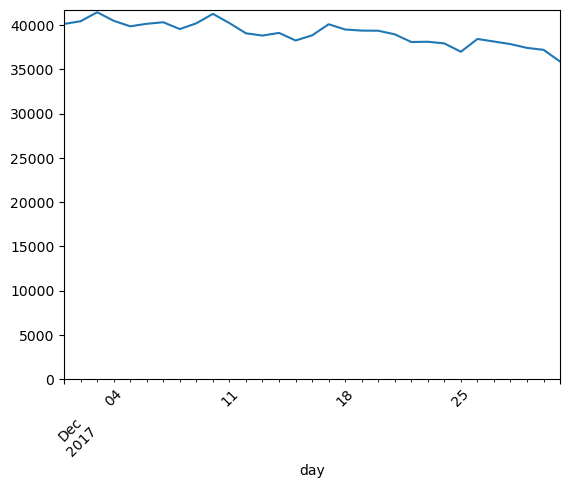

In [85]:
# график показывает число уникальных пользователей в определенный день
df.groupby('day')['uid'].nunique().plot(rot=45, ylim=0)

## Количество попыток на каждый уровень

<Axes: xlabel='level'>

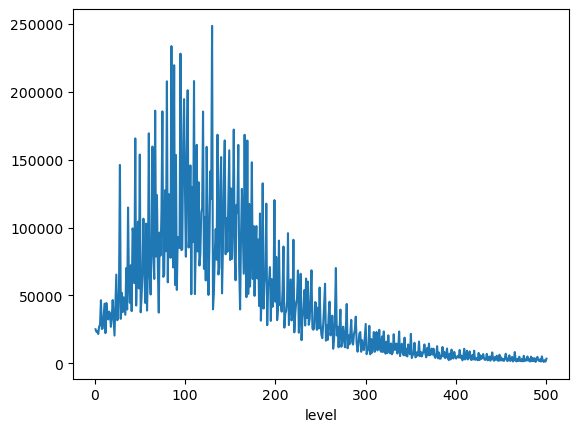

In [100]:
df.groupby('level')['uid'].count().plot()

In [104]:
t = df.groupby(['level','uid'])['uid'].count()

In [108]:
t.name = 'count'

In [114]:
t

level  uid                           
1      M001TWRFNWc5MjQ1MDI3MTAyMjE5MA     1
       M001VTlGalU5MzcwMTI3MTAyMjE5Mg     1
       M010Z2VmOFgzMzgwMTI3MTAyMjE4Mg     1
       M01QQlBMVmo1NTcyODA3MTAyMjE4MQ     1
       M01TMDNDdzA0MDkwNzE3MTAyMjE2MA     1
                                         ..
500    eTdScDhBVVE2NTUwNDE3MTAyMDE2MA     1
       eU5xSFk1R3kzMjMxNzE3MTAyOTAxMg    11
       eVZZWENPOVY0MjEzMzI3MTAyMDE1MA     7
       elpFRWtucDUzMjIzNDE3MTAyMDE3MA    14
       emxFbndWVVcwMTUxMDI3MTAyMDE5MQ     5
Name: count, Length: 3803858, dtype: int64

In [118]:
t = t.reset_index()

In [122]:
tt =t.groupby(['level'])['count'].agg(['count', 'mean', 'median'])

In [124]:
tt

,count,mean,median
level,,,
1,24162,1.041180,1.0
2,22177,1.051224,1.0
3,21415,1.103619,1.0
4,20916,1.034423,1.0
5,20625,1.318400,1.0
...,...,...,...
496,433,4.762125,3.0
497,408,2.813725,2.0
498,412,5.847087,4.0


## Количество уникальных пользователей на каждом уровне

<Axes: xlabel='level'>

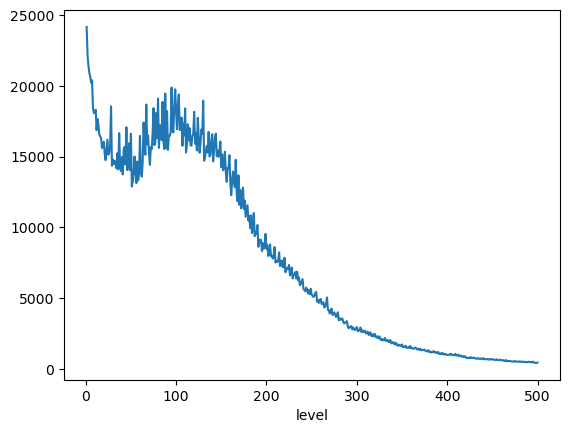

In [126]:
tt['count'].plot()

## Среднее число попыток на каждом уровне 

<Axes: xlabel='level'>

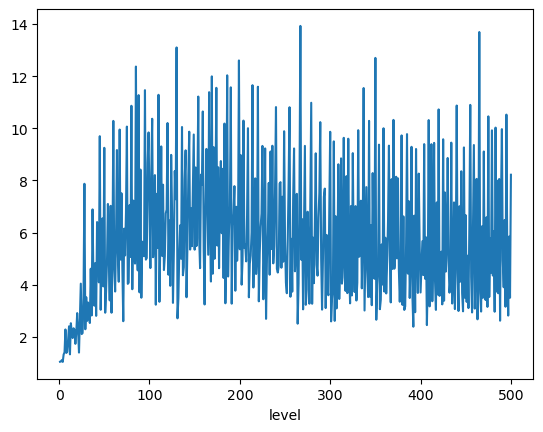

In [128]:
tt['mean'].plot()

## Медианное число попыток на каждом уровне

<Axes: xlabel='level'>

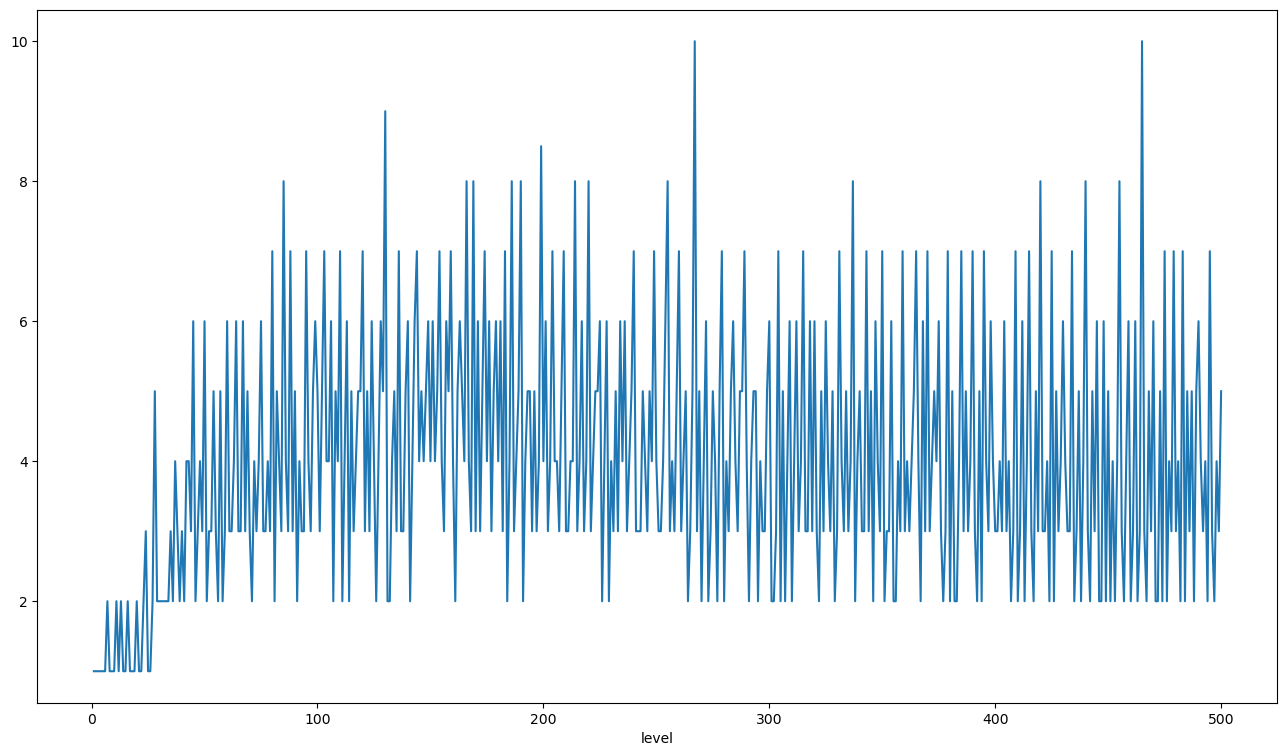

In [132]:
tt['median'].plot(figsize = (16,9))

<Axes: xlabel='level'>

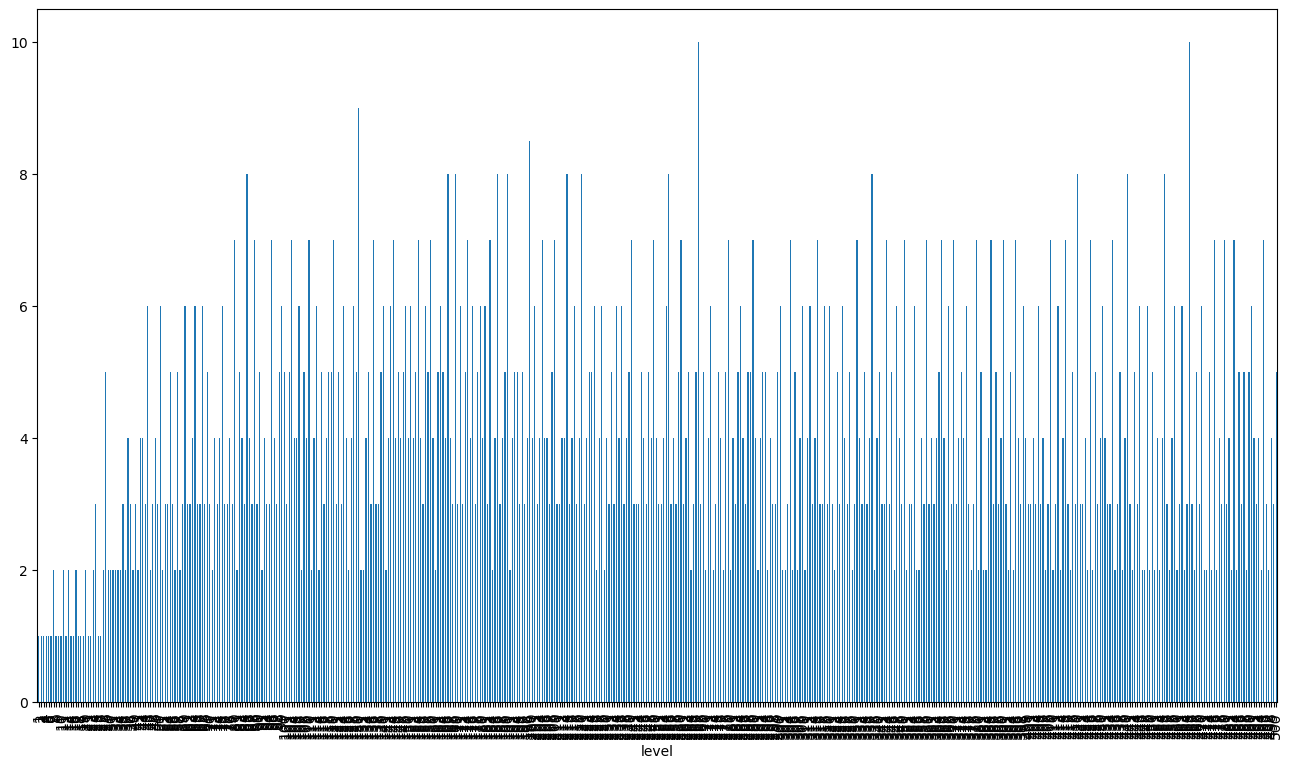

In [134]:
tt['median'].plot(kind = 'bar', figsize = (16,9))

In [142]:
t = tt['median'].reset_index()

In [148]:
t['median'].value_counts()

median
3.0     124
4.0      94
2.0      88
5.0      70
6.0      50
7.0      39
1.0      19
8.0      12
10.0      2
9.0       1
8.5       1
Name: count, dtype: int64

## Вывод 

1. Сложность сначала низкая, потом повышается и остается примерно на одном уровне.
2. Сложность уровней чередуется, т.е. сначала идет сложный, потом легкий.
3. Число попыток и уникальных пользователей с ростом уровня снижается (примерно на 150-200 уровне). Возможно это связано с интересом игроков проходить уровни так далеко.